# SecureBank Loan Default Prediction
## ALY6020:Predictive Analytics Assignment
**Prepared for:** Chief Risk Officer, SecureBank
**By Cheryl Mushangwe**
**Date:** June 2026


---


## Step 1: Business Problem Definition

SecureBank needs to predict whether a loan applicant will default **before** the loan
is approved. This is a binary classification problem:

| Error Type | Meaning | Cost |
|---|---|---|
| **False Negative (FN)** | Approve a borrower who defaults | **$15,000** |
| **False Positive (FP)** | Reject a creditworthy borrower | **$2,000** |

The **7.5 : 1 cost ratio** means recall (minimising FN) matters far more than
precision for this use case. A naive 50% threshold is sub-optimal; the cost-optimal
threshold is approximately `cost_FP / (cost_FP + cost_FN) ≈ 0.12`.

**Success criterion:** AUC > 0.75, recall > 0.70 on the test set.


In [25]:
#Imports
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay,
)
import statsmodels.api as sm

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.labelsize": 11})

RED, GREEN, BLUE, ORG = "#C0392B", "#1E8449", "#1A5276", "#CA6F1E"
DATA = "../data/loan_default.csv"
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Data Cleaning & Initial Findings
### 2.1 Load & Inspect

In [26]:
# Load dataset
df_raw = pd.read_csv(DATA)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (2559, 21)


,Checking_Account_Status,Loan_Duration_Months,Credit_History,Loan_Purpose,Loan_Amount,Savings_Account_Status,Employment_Duration,Installment_Rate_Pct,Personal_Status,Other_Debtors_Guarantors,...,Property_Type,Age,Other_Installment_Plans,Housing_Type,Num_Existing_Credits,Job_Type,Num_Dependents,Has_Telephone,Is_Foreign_Worker,Loan_Default
0,no checking account,25.0000,existing credits paid back duly,furniture/equipment,1020.0000,unknown / no savings,4 - 7 years,3,male : single,none,...,unknown / no property,30.0000,stores,own,1,skilled employee / official,2,yes,yes,No
1,< 0 DM,11.0000,critical account / other credits existing,education,1380.0000,< 100 DM,>= 7 years,4,male : single,none,...,real estate,54.0000,stores,own,1,unskilled - resident,1,no,yes,No
2,0 - 200 DM,18.0000,existing credits paid back duly,car (used),12976.0000,< 100 DM,unemployed,3,female : divorced/separated/married,none,...,unknown / no property,38.0000,none,for free,1,management / self-employed / highly qualified,1,yes,yes,Yes
3,< 0 DM,25.0000,existing credits paid back duly,car (used),3004.0000,unknown / no savings,4 - 7 years,3,female : divorced/separated/married,none,...,real estate,24.0000,none,rent,1,skilled employee / official,1,yes,yes,No
4,0 - 200 DM,18.0000,delay in paying off,business,2427.0000,unknown / no savings,>= 7 years,4,male : single,none,...,building society savings / life insurance,42.0000,none,own,2,skilled employee / official,1,no,yes,No


In [27]:
# Summary statistics for numerical variables
NUM_VARS = [
    "Loan_Duration_Months", "Loan_Amount", "Installment_Rate_Pct",
    "Current_Residence_Years", "Age", "Num_Existing_Credits", "Num_Dependents",
]
df_raw[NUM_VARS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Loan_Duration_Months,2483.0000,21.0000,12.3200,0.0000,12.0000,18.0000,26.0000,72.0000
Loan_Amount,2432.0000,3290.7800,2887.6500,-5410.0000,1374.0000,2321.5000,4009.5000,19972.0000
Installment_Rate_Pct,2559.0000,2.9200,1.1000,1.0000,2.0000,3.0000,4.0000,4.0000
Current_Residence_Years,2559.0000,2.8100,1.1100,1.0000,2.0000,3.0000,4.0000,4.0000
Age,2456.0000,35.5000,11.5400,14.0000,27.0000,33.0000,42.0000,78.0000
Num_Existing_Credits,2559.0000,1.4700,0.6600,1.0000,1.0000,1.0000,2.0000,4.0000
Num_Dependents,2559.0000,1.2000,0.4000,1.0000,1.0000,1.0000,1.0000,2.0000


In [28]:
# Missing values
missing_ser = df_raw.isnull().sum()
missing_df  = pd.DataFrame({
    "Missing Count": missing_ser,
    "Missing %":     (missing_ser / len(df_raw) * 100).round(2),
}).loc[missing_ser > 0]
print("Variables with missing data:")
display(missing_df)

print(f"\nNegative Loan_Amount : {(df_raw['Loan_Amount'] < 0).sum()}")
print(f"Age < 18             : {(df_raw['Age'].dropna() < 18).sum()}")
print(f"Age > 100            : {(df_raw['Age'].dropna() > 100).sum()}")

Variables with missing data:


,Missing Count,Missing %
Loan_Duration_Months,76,2.9700
Loan_Amount,127,4.9600
Employment_Duration,102,3.9900
Age,103,4.0300



Negative Loan_Amount : 5
Age < 18             : 3
Age > 100            : 0


### 2.2 Data Cleaning Decisions

| Issue | Count | Action |
|---|---|---|
| Missing Age | 103 | Impute with column **median** |
| Missing Loan_Duration_Months | 76 | Impute with column **median** |
| Missing Loan_Amount | 127 | Impute with column **median** |
| Missing Employment_Duration | 102 | Handled during ordinal encoding (default = 1) |
| Negative Loan_Amount | 5 | Replace with **median** |
| Age < 18 | 3 | Replace with **median** |

Median imputation is preferred over mean for skewed distributions, as it is
resistant to the influence of extreme values.


In [29]:
# Apply cleaning
df = df_raw.copy()

for col in ["Age", "Loan_Duration_Months", "Loan_Amount"]:
    med = df[col].median()
    df[col] = df[col].fillna(med)

age_median  = df["Age"].median()
loan_median = df["Loan_Amount"].median()
df.loc[df["Age"] < 18, "Age"]         = age_median
df.loc[df["Loan_Amount"] < 0, "Loan_Amount"] = loan_median

print("Post-cleaning NaN check:")
print(df[NUM_VARS].isnull().sum())
print(f"\nNegative Loan_Amount after cleaning: {(df['Loan_Amount'] < 0).sum()}")

Post-cleaning NaN check:
Loan_Duration_Months       0
Loan_Amount                0
Installment_Rate_Pct       0
Current_Residence_Years    0
Age                        0
Num_Existing_Credits       0
Num_Dependents             0
dtype: int64

Negative Loan_Amount after cleaning: 0


### 2.3 Class Distribution

No Default : 1,793  (70.1%)
Default    : 766  (29.9%)


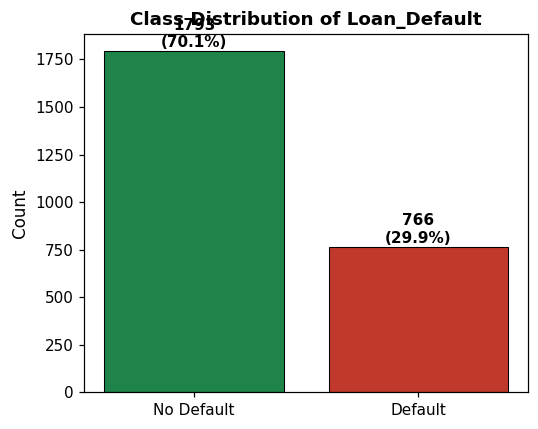


The 30/70 split is moderate imbalance - accuracy alone is misleading.
We will use Recall, F1, and AUC as primary evaluation metrics.


In [30]:
# Target variable distribution
target_counts = df["Loan_Default"].value_counts()
default_rate  = target_counts.get("Yes", 0) / len(df) * 100

print(f"No Default : {target_counts.get('No',0):,}  ({100-default_rate:.1f}%)")
print(f"Default    : {target_counts.get('Yes',0):,}  ({default_rate:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No Default", "Default"],
       [target_counts.get("No",0), target_counts.get("Yes",0)],
       color=[GREEN, RED], edgecolor="black", linewidth=0.7)
ax.set_ylabel("Count"); ax.set_title("Class Distribution of Loan_Default")
for i, v in enumerate([target_counts.get("No",0), target_counts.get("Yes",0)]):
    ax.text(i, v+20, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
print("\nThe 30/70 split is moderate imbalance - accuracy alone is misleading.")
print("We will use Recall, F1, and AUC as primary evaluation metrics.")

### 2.4 Encoding Strategy

| Strategy | Variables | Rationale |
|---|---|---|
| **Ordinal** | Checking_Account_Status, Savings_Account_Status, Employment_Duration, Credit_History | Natural risk-ordered scale; preserves monotonic relationship |
| **One-Hot (OHE)** | Loan_Purpose, Personal_Status, Other_Debtors_Guarantors, Property_Type, Other_Installment_Plans, Housing_Type, Job_Type | No natural order; dummy coding avoids false ordinality |
| **Binary (0/1)** | Has_Telephone, Is_Foreign_Worker | Two-category nominal |


In [31]:
# Ordinal encoding
df["Target"] = (df["Loan_Default"] == "Yes").astype(int)

df["Checking_Ord"]      = df["Checking_Account_Status"].map(
    {"< 0 DM": 0, "0 - 200 DM": 1, ">= 200 DM": 2, "no checking account": 3}).fillna(1)

df["Savings_Ord"]       = df["Savings_Account_Status"].map(
    {"unknown / no savings": 0, "< 100 DM": 1, "100 - 500 DM": 2,
     "500 - 1000 DM": 3, ">= 1000 DM": 4}).fillna(0)

df["Employment_Ord"]    = df["Employment_Duration"].map(
    {"unemployed": 0, "< 1 year": 1, "1 - 4 years": 2,
     "4 - 7 years": 3, ">= 7 years": 4}).fillna(1)

df["CreditHistory_Ord"] = df["Credit_History"].map(
    {"no credits taken / all credits paid back duly": 0,
     "all credits at this bank paid back duly": 1,
     "existing credits paid back duly": 2,
     "delay in paying off": 3,
     "critical account / other credits existing": 4}).fillna(2)

# Binary encoding
df["Telephone_Bin"]     = (df["Has_Telephone"] == "yes").astype(int)
df["ForeignWorker_Bin"] = (df["Is_Foreign_Worker"] == "yes").astype(int)

# One-Hot encoding 
NOMINAL = ["Loan_Purpose","Personal_Status","Other_Debtors_Guarantors",
           "Property_Type","Other_Installment_Plans","Housing_Type","Job_Type"]
df_enc  = pd.get_dummies(df, columns=NOMINAL, drop_first=True, dtype=int)
OHE_FEATURES = [c for c in df_enc.columns if any(c.startswith(n+"_") for n in NOMINAL)]

ORDINAL_FEATURES = ["Checking_Ord","Savings_Ord","Employment_Ord","CreditHistory_Ord"]
BINARY_FEATURES  = ["Telephone_Bin","ForeignWorker_Bin"]
ALL_FEATURES     = NUM_VARS + ORDINAL_FEATURES + BINARY_FEATURES + OHE_FEATURES

X = df_enc[ALL_FEATURES].copy()
y = df_enc["Target"].copy()

assert X.isnull().sum().sum() == 0, "NaN remaining in feature matrix!"
print(f"Feature matrix ready - {len(ALL_FEATURES)} features, {len(X):,} records.")

Feature matrix ready - 37 features, 2,559 records.


### 2.5 EDA Visualizations

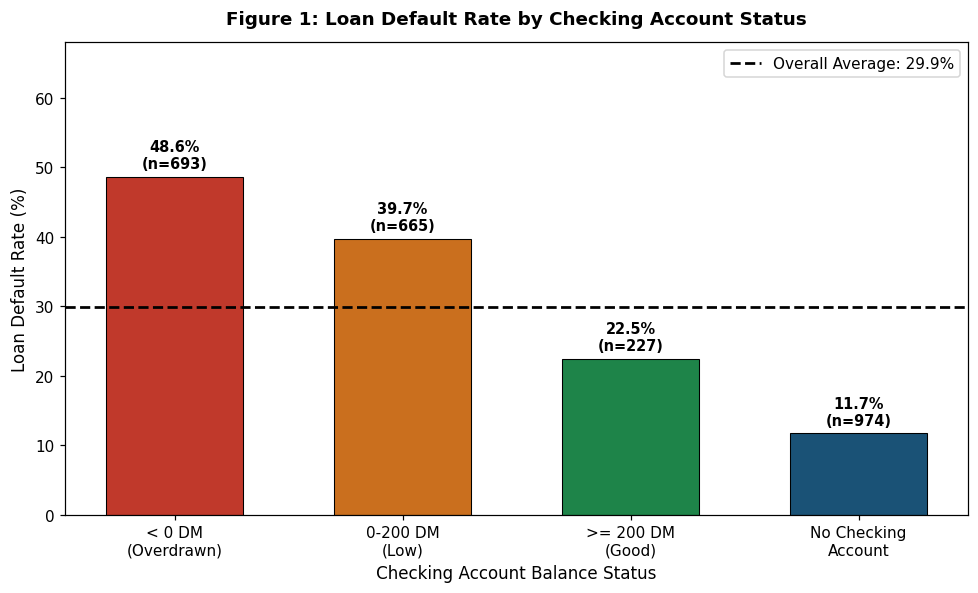

In [32]:
# Figure 1: Default rate by Checking Account Status
df["Default_Label"] = df["Target"].map({0:"No Default",1:"Default"})
avg_rate = df["Target"].mean() * 100
order_chk = ["< 0 DM","0 - 200 DM",">= 200 DM","no checking account"]
chk_pct   = df.groupby("Checking_Account_Status")["Target"].mean() * 100
chk_cnt   = df.groupby("Checking_Account_Status")["Target"].count()
xlabels   = ["< 0 DM\n(Overdrawn)","0-200 DM\n(Low)",">= 200 DM\n(Good)","No Checking\nAccount"]

fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.bar(range(4), [chk_pct.get(o,0) for o in order_chk],
              color=[RED,ORG,GREEN,BLUE], edgecolor="black", linewidth=0.7, width=0.6)
ax.set_xticks(range(4)); ax.set_xticklabels(xlabels, fontsize=10)
for bar, o in zip(bars, order_chk):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.8,
            f"{chk_pct.get(o,0):.1f}%\n(n={chk_cnt.get(o,0)})",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold")
ax.axhline(avg_rate, color="black", ls="--", lw=1.8, label=f"Overall Average: {avg_rate:.1f}%")
ax.set_ylim(0,68); ax.set_xlabel("Checking Account Balance Status")
ax.set_ylabel("Loan Default Rate (%)")
ax.set_title("Figure 1: Loan Default Rate by Checking Account Status", pad=12)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

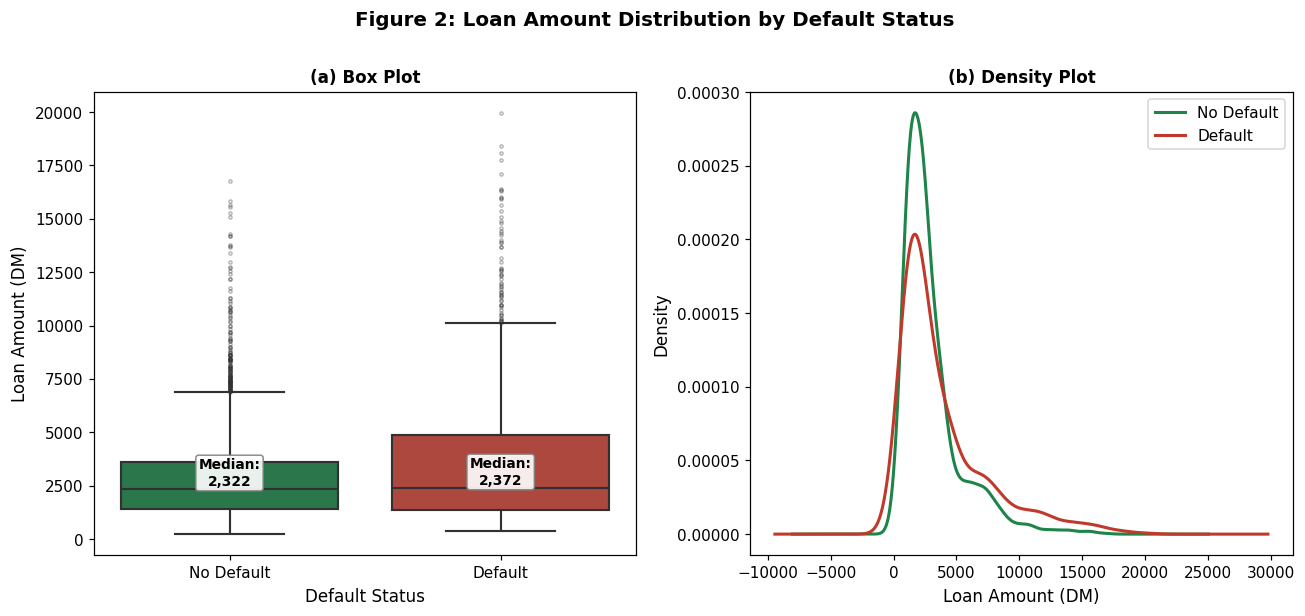

In [33]:
# Figure 2: Loan Amount by Default Status
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
pal = {"No Default": GREEN, "Default": RED}
sns.boxplot(data=df, x="Default_Label", y="Loan_Amount",
            palette=pal, ax=ax1, linewidth=1.4,
            flierprops={"marker":".","markersize":4,"alpha":0.35})
ax1.set_title("(a) Box Plot", fontsize=11, fontweight="bold")
ax1.set_xlabel("Default Status"); ax1.set_ylabel("Loan Amount (DM)")
for i, lbl in enumerate(["No Default","Default"]):
    med = df.loc[df["Default_Label"]==lbl,"Loan_Amount"].median()
    ax1.text(i, med+60, f"Median:\n{med:,.0f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="gray",alpha=0.9))
for lbl in ["No Default","Default"]:
    df.loc[df["Default_Label"]==lbl,"Loan_Amount"].plot(
        kind="kde", ax=ax2, color=pal[lbl], label=lbl, linewidth=2)
ax2.set_xlabel("Loan Amount (DM)"); ax2.set_ylabel("Density")
ax2.set_title("(b) Density Plot", fontsize=11, fontweight="bold"); ax2.legend()
fig.suptitle("Figure 2: Loan Amount Distribution by Default Status",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

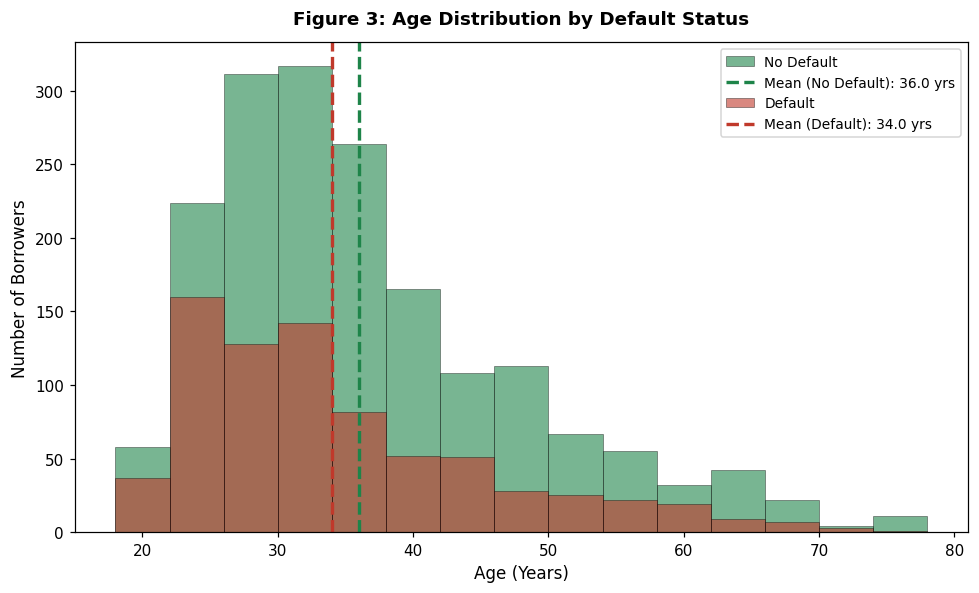

In [34]:
# Figure 3: Age Distribution by Default Status
bins = np.arange(18, 80, 4)
fig, ax = plt.subplots(figsize=(9,5.5))
for lbl, clr in [("No Default", GREEN), ("Default", RED)]:
    data = df.loc[df["Default_Label"]==lbl,"Age"]
    ax.hist(data, bins=bins, alpha=0.6, color=clr, label=lbl,
            edgecolor="black", linewidth=0.4)
    ax.axvline(data.mean(), color=clr, ls="--", lw=2.2,
               label=f"Mean ({lbl}): {data.mean():.1f} yrs")
ax.set_xlabel("Age (Years)"); ax.set_ylabel("Number of Borrowers")
ax.set_title("Figure 3: Age Distribution by Default Status", pad=12)
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

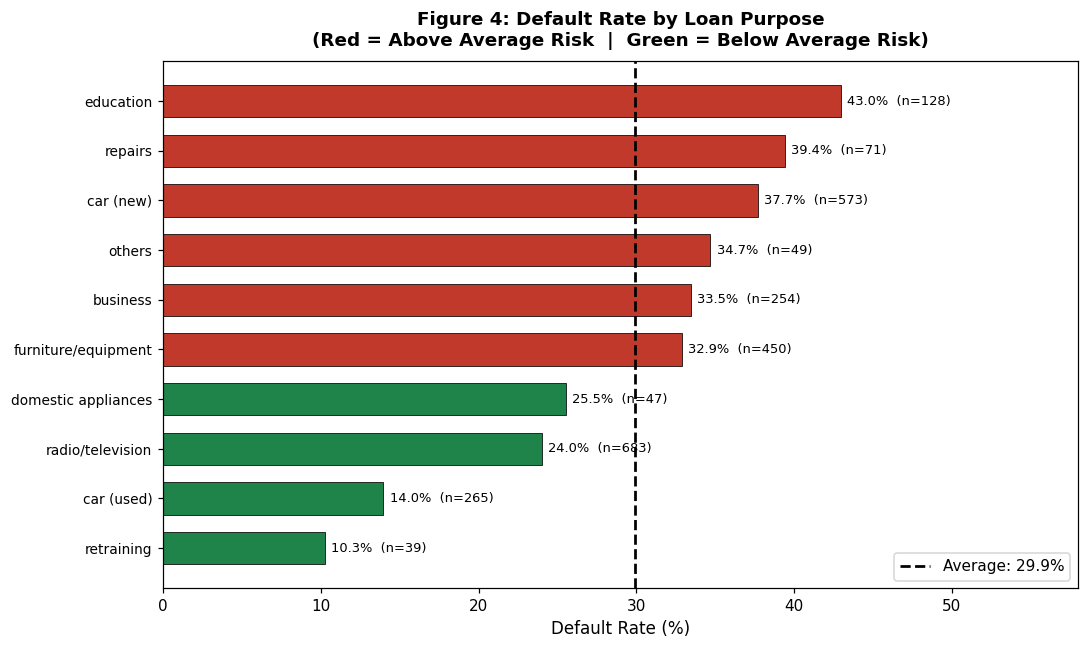

In [35]:
# Figure 4: Default Rate by Loan Purpose
purp_df = (df.groupby("Loan_Purpose")["Target"]
             .agg(["mean","count"])
             .rename(columns={"mean":"rate","count":"n"}).reset_index())
purp_df["pct"] = purp_df["rate"] * 100
purp_df = purp_df.sort_values("pct", ascending=True)
bar_c4  = [RED if x >= avg_rate else GREEN for x in purp_df["pct"]]

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(range(len(purp_df)), purp_df["pct"],
               color=bar_c4, edgecolor="black", linewidth=0.5, height=0.65)
ax.set_yticks(range(len(purp_df))); ax.set_yticklabels(purp_df["Loan_Purpose"], fontsize=9)
for bar, row in zip(bars, purp_df.itertuples()):
    ax.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2.,
            f"{row.pct:.1f}%  (n={row.n})", va="center", fontsize=8.5)
ax.axvline(avg_rate, color="black", ls="--", lw=1.8, label=f"Average: {avg_rate:.1f}%")
ax.set_xlabel("Default Rate (%)")
ax.set_title("Figure 4: Default Rate by Loan Purpose\n"
             "(Red = Above Average Risk  |  Green = Below Average Risk)", pad=10)
ax.set_xlim(0,58); ax.legend(fontsize=10); plt.tight_layout(); plt.show()

## Step 3: Algorithm Explanation & Model Results

### 3.1 Why Classification?
The target variable `Loan_Default` is **binary** (Yes / No), making this a
**classification** - not regression-problem. We need group membership, not a
continuous quantity.

**Why Logistic Regression?**
- Produces calibrated probabilities -> directly interpretable as P(default)
- Coefficients yield **odds ratios** -> explainable to regulators and credit analysts
- Efficient, well-understood, baseline for binary outcomes

**Why SVM (RBF kernel)?**
- Finds the maximum-margin decision boundary, robust to high-dimensional OHE features
- RBF kernel captures **non-linear** relationships without explicit feature engineering
- Strong discriminatory power - useful as a performance benchmark

### 3.2 Train / Test Split & Scaling


In [36]:
# 80 / 20 stratified split (preserves class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]:,} records  "
      f"(default rate: {y_train.mean():.2%})")
print(f"Test set     : {X_test.shape[0]:,} records  "
      f"(default rate: {y_test.mean():.2%})")

# StandardScaler: zero mean, unit variance (required for SVM; improves LR stability)
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

# Keep as DataFrames for statsmodels backward elimination
X_tr_df = pd.DataFrame(X_tr_sc, columns=ALL_FEATURES)
X_te_df = pd.DataFrame(X_te_sc, columns=ALL_FEATURES)
print("\nScaling complete.")

Training set : 2,047 records  (default rate: 29.95%)
Test set     : 512 records  (default rate: 29.88%)

Scaling complete.


### 3.3 Model 1 - Logistic Regression (Baseline, All Features)

In [37]:
# Train using all 37 features; C=1.0 L2 regularisation
lr1 = LogisticRegression(max_iter=3000, random_state=42, C=1.0, solver="lbfgs")
lr1.fit(X_tr_sc, y_train)

yp1  = lr1.predict(X_te_sc)
ypr1 = lr1.predict_proba(X_te_sc)[:, 1]

cm1   = confusion_matrix(y_test, yp1)
acc1  = accuracy_score(y_test, yp1)
prec1 = precision_score(y_test, yp1)
rec1  = recall_score(y_test, yp1)
f1_1  = f1_score(y_test, yp1)
fpr1, tpr1, _ = roc_curve(y_test, ypr1)
auc1  = auc(fpr1, tpr1)

print("=== Model 1: LR Baseline ===")
print(f"Accuracy  : {acc1:.4f}")
print(f"Precision : {prec1:.4f}")
print(f"Recall    : {rec1:.4f}")
print(f"F1-Score  : {f1_1:.4f}")
print(f"AUC       : {auc1:.4f}")

=== Model 1: LR Baseline ===
Accuracy  : 0.7656
Precision : 0.6341
Recall    : 0.5098
F1-Score  : 0.5652
AUC       : 0.7745


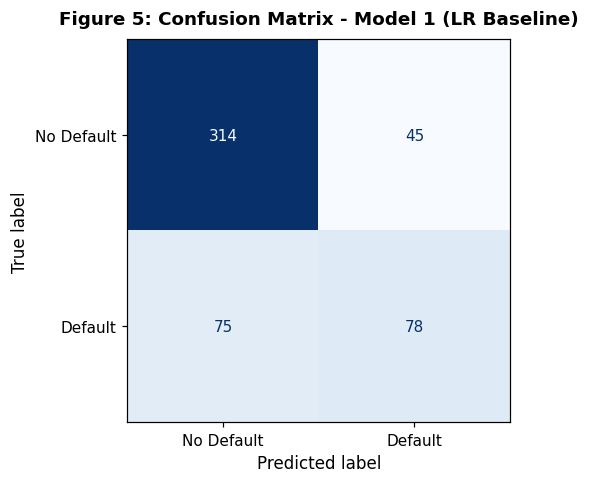


TP=78  FP=45  FN=75  TN=314
Cost of errors (test set): FN x $15,000 = $1,125,000  |  FP x $2,000 = $90,000
Total error cost: $1,215,000


In [38]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm1, display_labels=["No Default","Default"]).plot(
    ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.set_title("Figure 5: Confusion Matrix - Model 1 (LR Baseline)", pad=10)
plt.tight_layout(); plt.show()

tn,fp,fn,tp = cm1.ravel()
print(f"\nTP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Cost of errors (test set): FN x $15,000 = ${fn*15000:,}  |  FP x $2,000 = ${fp*2000:,}")
print(f"Total error cost: ${fn*15000 + fp*2000:,}")

In [39]:
# Odds ratios - top risk-increasing and risk-reducing features
coef_df = pd.DataFrame({
    "Feature":    ALL_FEATURES,
    "Coefficient": lr1.coef_[0],
    "Odds_Ratio":  np.exp(lr1.coef_[0]),
}).sort_values("Odds_Ratio", ascending=False)

print("=== Top 10 Risk-INCREASING Features (Odds Ratio > 1) ===")
display(coef_df.head(10).reset_index(drop=True))

print("\n=== Top 5 Risk-REDUCING Features (Odds Ratio < 1) ===")
display(coef_df.tail(5).reset_index(drop=True))

=== Top 10 Risk-INCREASING Features (Odds Ratio > 1) ===


,Feature,Coefficient,Odds_Ratio
0,Loan_Duration_Months,0.3076,1.3601
1,Installment_Rate_Pct,0.3027,1.3535
2,Loan_Amount,0.2779,1.3204
3,Loan_Purpose_car (new),0.2657,1.3043
4,ForeignWorker_Bin,0.1786,1.1955
5,Property_Type_unknown / no property,0.1755,1.1918
6,Loan_Purpose_repairs,0.1665,1.1811
7,Housing_Type_rent,0.1394,1.1496
8,Loan_Purpose_education,0.1212,1.1288
9,Job_Type_unskilled - resident,0.0932,1.0977



=== Top 5 Risk-REDUCING Features (Odds Ratio < 1) ===


,Feature,Coefficient,Odds_Ratio
0,CreditHistory_Ord,-0.2502,0.7786
1,Personal_Status_male : single,-0.2788,0.7567
2,Other_Debtors_Guarantors_guarantor,-0.3347,0.7155
3,Loan_Purpose_car (used),-0.3476,0.7064
4,Checking_Ord,-0.8160,0.4422


#### Odds Ratio Interpretation (Model 1)

**Note:** Features were standardised, so each odds ratio represents the effect of
a **1-standard-deviation** increase in that variable.

1. **Loan_Duration_Months** - A 1-SD increase in loan duration multiplies the odds
   of default by approximately 1.36 (36% increase). Longer commitment periods expose
   the bank to greater income and life-event uncertainty.

2. **Installment_Rate_Pct** - A 1-SD increase in the instalment-to-income ratio
   increases odds of default by ~35%. Higher payment burden relative to income is a
   classic predictor of repayment stress.

3. **Checking_Ord** (risk-reducing) - A 1-SD improvement in checking account balance
   status reduces odds of default by more than half (OR ≈ 0.44). This is the
   strongest protective signal in the dataset - liquid checking accounts indicate
   financial health and buffer capacity.


### 3.4 Model 2 - Optimised Logistic Regression (Backward Elimination)

In [40]:
def backward_elim(X_df, y_ser, threshold=0.05):
    """Iteratively remove the highest p-value feature until all p < threshold."""
    features = list(X_df.columns)
    removed_log = []
    itr = 0
    while True:
        itr += 1
        X_sm = sm.add_constant(X_df[features], has_constant="add")
        try:
            res  = sm.Logit(
                y_ser.reset_index(drop=True),
                X_sm.reset_index(drop=True)
            ).fit(disp=False, maxiter=600, method="bfgs")
            pvals   = res.pvalues.iloc[1:]    # exclude constant
            worst_p = pvals.max()
            worst_f = pvals.idxmax()
            if worst_p > threshold:
                features.remove(worst_f)
                removed_log.append((worst_f, round(worst_p,4)))
                print(f"  Iter {itr:3d}: removed '{worst_f}'  (p={worst_p:.4f})")
            else:
                print(f"  Converged - {len(features)} features remain (max p={worst_p:.4f})")
                break
        except Exception as exc:
            print(f"  Stopped at iter {itr}: {exc}"); break
    return features, removed_log

sel_features, removed_log = backward_elim(X_tr_df, y_train, threshold=0.05)
print(f"\nFinal selected features ({len(sel_features)}):")
for f in sel_features: print(f"  - {f}")

  Iter   1: removed 'Job_Type_unemployed / unskilled - non-resident'  (p=0.9841)
  Iter   2: removed 'Personal_Status_male : divorced/separated'  (p=0.9850)
  Iter   3: removed 'Other_Installment_Plans_stores'  (p=0.9050)
  Iter   4: removed 'Loan_Purpose_radio/television'  (p=0.8064)
  Iter   5: removed 'Loan_Purpose_domestic appliances'  (p=0.6450)
  Iter   6: removed 'Num_Dependents'  (p=0.5651)
  Iter   7: removed 'Num_Existing_Credits'  (p=0.5285)
  Iter   8: removed 'Loan_Purpose_furniture/equipment'  (p=0.5016)
  Iter   9: removed 'Current_Residence_Years'  (p=0.5144)
  Iter  10: removed 'Job_Type_skilled employee / official'  (p=0.5096)
  Iter  11: removed 'Housing_Type_own'  (p=0.4902)
  Iter  12: removed 'Job_Type_unskilled - resident'  (p=0.3589)
  Iter  13: removed 'Property_Type_car or other'  (p=0.3479)
  Iter  14: removed 'Personal_Status_male : married/widowed'  (p=0.3255)
  Iter  15: removed 'Loan_Purpose_others'  (p=0.3097)
  Iter  16: removed 'Employment_Ord'  (p=0.3

In [41]:
# Train Model 2 on selected features
X_tr2 = X_tr_df[sel_features].values
X_te2 = X_te_df[sel_features].values

lr2  = LogisticRegression(max_iter=3000, random_state=42, C=1.0, solver="lbfgs")
lr2.fit(X_tr2, y_train)

yp2   = lr2.predict(X_te2)
ypr2  = lr2.predict_proba(X_te2)[:, 1]

cm2   = confusion_matrix(y_test, yp2)
acc2  = accuracy_score(y_test, yp2)
prec2 = precision_score(y_test, yp2)
rec2  = recall_score(y_test, yp2)
f1_2  = f1_score(y_test, yp2)
fpr2, tpr2, _ = roc_curve(y_test, ypr2)
auc2  = auc(fpr2, tpr2)

print("=== Model 2: LR Optimised ===")
print(f"Accuracy  : {acc2:.4f}")
print(f"Precision : {prec2:.4f}")
print(f"Recall    : {rec2:.4f}")
print(f"F1-Score  : {f1_2:.4f}")
print(f"AUC       : {auc2:.4f}")

=== Model 2: LR Optimised ===
Accuracy  : 0.7617
Precision : 0.6325
Recall    : 0.4837
F1-Score  : 0.5481
AUC       : 0.7735


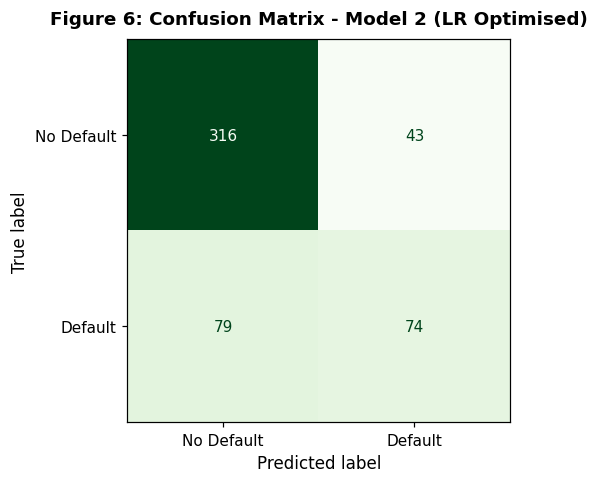

TP=74  FP=43  FN=79  TN=316
Total error cost: $1,271,000


In [42]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm2, display_labels=["No Default","Default"]).plot(
    ax=ax, colorbar=False, cmap="Greens", values_format="d")
ax.set_title("Figure 6: Confusion Matrix - Model 2 (LR Optimised)", pad=10)
plt.tight_layout(); plt.show()

tn2,fp2,fn2,tp2 = cm2.ravel()
print(f"TP={tp2}  FP={fp2}  FN={fn2}  TN={tn2}")
print(f"Total error cost: ${fn2*15000 + fp2*2000:,}")

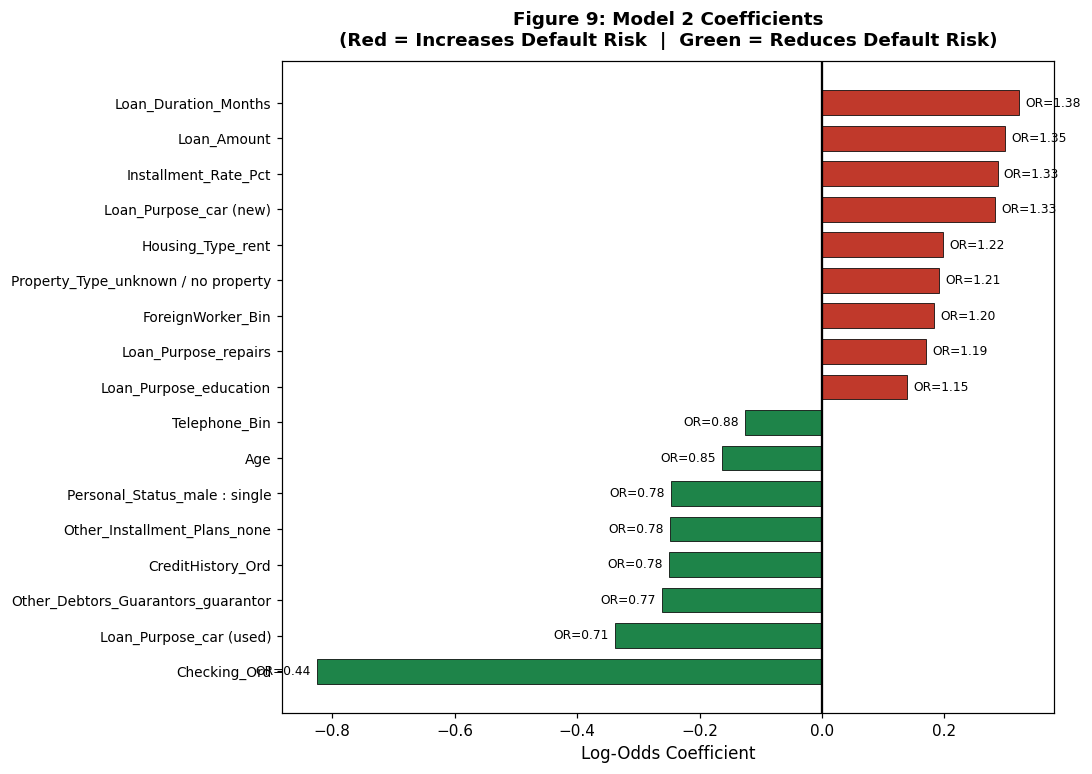

In [43]:
# Feature coefficient chart (Figure 9)
sel_coef = pd.DataFrame({
    "Feature":    sel_features,
    "Coefficient": lr2.coef_[0],
    "Odds_Ratio":  np.exp(lr2.coef_[0]),
}).sort_values("Coefficient")

fc = [RED if c > 0 else GREEN for c in sel_coef["Coefficient"]]
fig, ax = plt.subplots(figsize=(10, max(5, len(sel_features)*0.42)))
ax.barh(range(len(sel_coef)), sel_coef["Coefficient"],
        color=fc, edgecolor="black", linewidth=0.5, height=0.7)
ax.set_yticks(range(len(sel_coef))); ax.set_yticklabels(sel_coef["Feature"], fontsize=9)
ax.axvline(0, color="black", lw=1.5)
for i,(coef,oratio) in enumerate(zip(sel_coef["Coefficient"], sel_coef["Odds_Ratio"])):
    ax.text(coef+(0.01 if coef>=0 else -0.01), i, f"OR={oratio:.2f}",
            va="center", ha="left" if coef>=0 else "right", fontsize=8)
ax.set_xlabel("Log-Odds Coefficient")
ax.set_title("Figure 9: Model 2 Coefficients\n"
             "(Red = Increases Default Risk  |  Green = Reduces Default Risk)", pad=10)
plt.tight_layout(); plt.show()

### 3.5 Model 3 - SVM with RBF Kernel

In [44]:
# RBF kernel - maps features to infinite-dimensional space via Gaussian similarity
# C=1.0 (regularisation), gamma='scale' = 1/(n_features * Var(X))
svm = SVC(kernel="rbf", probability=True, random_state=42, C=1.0, gamma="scale")
svm.fit(X_tr_sc, y_train)

yp3  = svm.predict(X_te_sc)
ypr3 = svm.predict_proba(X_te_sc)[:, 1]

cm3   = confusion_matrix(y_test, yp3)
acc3  = accuracy_score(y_test, yp3)
prec3 = precision_score(y_test, yp3)
rec3  = recall_score(y_test, yp3)
f1_3  = f1_score(y_test, yp3)
fpr3, tpr3, _ = roc_curve(y_test, ypr3)
auc3  = auc(fpr3, tpr3)

print("=== Model 3: SVM (RBF) ===")
print(f"Accuracy  : {acc3:.4f}")
print(f"Precision : {prec3:.4f}")
print(f"Recall    : {rec3:.4f}")
print(f"F1-Score  : {f1_3:.4f}")
print(f"AUC       : {auc3:.4f}")

=== Model 3: SVM (RBF) ===
Accuracy  : 0.8398
Precision : 0.8447
Recall    : 0.5686
F1-Score  : 0.6797
AUC       : 0.8816


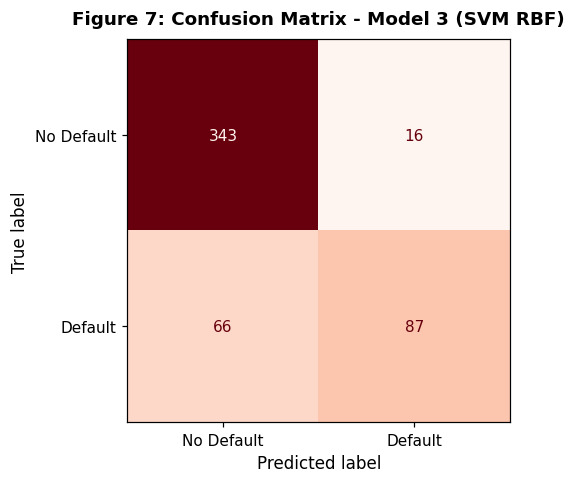

TP=87  FP=16  FN=66  TN=343
Total error cost: $1,022,000


In [45]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm3, display_labels=["No Default","Default"]).plot(
    ax=ax, colorbar=False, cmap="Reds", values_format="d")
ax.set_title("Figure 7: Confusion Matrix - Model 3 (SVM RBF)", pad=10)
plt.tight_layout(); plt.show()

tn3,fp3,fn3,tp3 = cm3.ravel()
print(f"TP={tp3}  FP={fp3}  FN={fn3}  TN={tn3}")
print(f"Total error cost: ${fn3*15000 + fp3*2000:,}")

### 3.6 ROC Curves - All Three Models

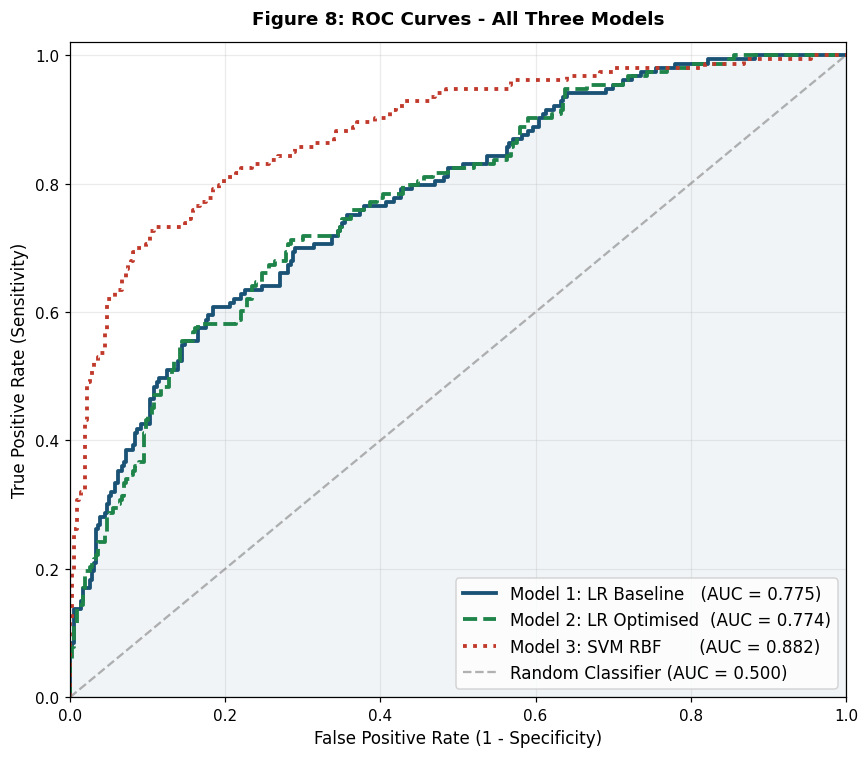

In [46]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr1, tpr1, color=BLUE,  lw=2.5,       label=f"Model 1: LR Baseline   (AUC = {auc1:.3f})")
ax.plot(fpr2, tpr2, color=GREEN, lw=2.5, ls="--", label=f"Model 2: LR Optimised  (AUC = {auc2:.3f})")
ax.plot(fpr3, tpr3, color=RED,   lw=2.5, ls=":",  label=f"Model 3: SVM RBF       (AUC = {auc3:.3f})")
ax.plot([0,1],[0,1], color="gray", lw=1.5, ls="--", alpha=0.6, label="Random Classifier (AUC = 0.500)")
ax.fill_between(fpr1, tpr1, alpha=0.06, color=BLUE)
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("Figure 8: ROC Curves - All Three Models", pad=12)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.25); plt.tight_layout(); plt.show()

### 3.7 Model Comparison Summary

In [47]:
comparison = pd.DataFrame({
    "Model":      ["LR Baseline", "LR Optimised", "SVM (RBF)"],
    "# Features": [len(ALL_FEATURES), len(sel_features), len(ALL_FEATURES)],
    "Accuracy":   [acc1, acc2, acc3],
    "Precision":  [prec1, prec2, prec3],
    "Recall":     [rec1, rec2, rec3],
    "F1-Score":   [f1_1, f1_2, f1_3],
    "AUC":        [auc1, auc2, auc3],
})
print("=== Model Comparison ===")
display(comparison)

print("\n--- Precision-Recall Trade-Off ---")
print("High precision  -> fewer false rejects, but more defaulters slip through ($15,000 each)")
print("High recall     -> catches more defaulters, but rejects more good borrowers ($2,000 each)")
print("Given 7.5:1 cost ratio, we should PRIORITISE RECALL over precision.")
print("SVM achieves the highest AUC and best overall F1; LR Baseline provides interpretability.")

=== Model Comparison ===


,Model,# Features,Accuracy,Precision,Recall,F1-Score,AUC
0,LR Baseline,37,0.7656,0.6341,0.5098,0.5652,0.7745
1,LR Optimised,17,0.7617,0.6325,0.4837,0.5481,0.7735
2,SVM (RBF),37,0.8398,0.8447,0.5686,0.6797,0.8816



--- Precision-Recall Trade-Off ---
High precision  -> fewer false rejects, but more defaulters slip through ($15,000 each)
High recall     -> catches more defaulters, but rejects more good borrowers ($2,000 each)
Given 7.5:1 cost ratio, we should PRIORITISE RECALL over precision.
SVM achieves the highest AUC and best overall F1; LR Baseline provides interpretability.


### 3.8 Cost-Optimal Decision Threshold (Model 2)

Cost-optimal threshold: 0.09  (Total cost: $592,000)
Default (0.50) threshold total cost: $1,271,000


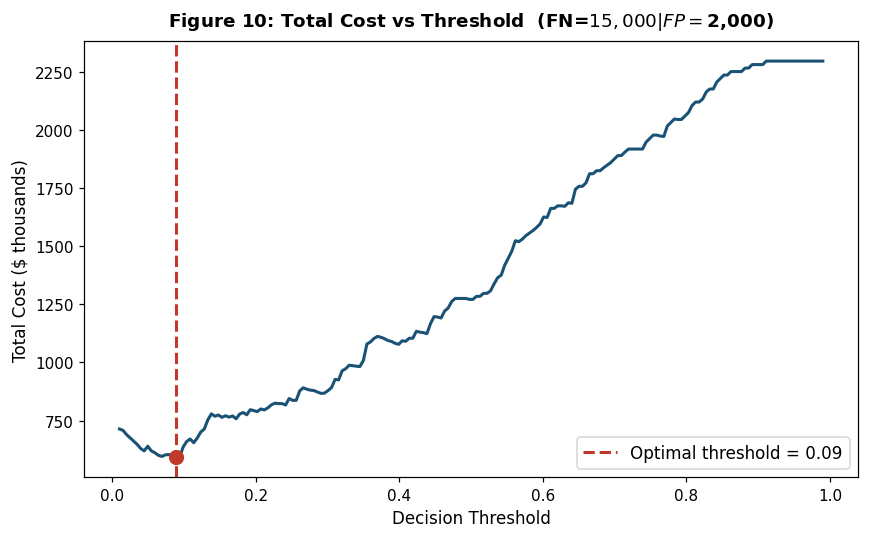


At threshold 0.09:
  Recall   : 0.9477
  Precision: 0.3806
  F1       : 0.5431


In [48]:
COST_FN, COST_FP = 15000, 2000
thresholds = np.linspace(0.01, 0.99, 200)
costs = []
for t in thresholds:
    yp_t = (ypr2 >= t).astype(int)
    fn   = ((yp_t == 0) & (y_test == 1)).sum()
    fp   = ((yp_t == 1) & (y_test == 0)).sum()
    costs.append(fn * COST_FN + fp * COST_FP)

costs = np.array(costs)
opt_idx = np.argmin(costs)
opt_thr = thresholds[opt_idx]
print(f"Cost-optimal threshold: {opt_thr:.2f}  (Total cost: ${costs[opt_idx]:,.0f})")
print(f"Default (0.50) threshold total cost: ${costs[np.argmin(np.abs(thresholds-0.5))]:,.0f}")

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(thresholds, costs/1000, color=BLUE, lw=2)
ax.axvline(opt_thr, color=RED, lw=2, ls="--", label=f"Optimal threshold = {opt_thr:.2f}")
ax.scatter([opt_thr],[costs[opt_idx]/1000], color=RED, zorder=5, s=80)
ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Total Cost ($ thousands)")
ax.set_title(f"Figure 10: Total Cost vs Threshold  (FN=${COST_FN:,}  |  FP=${COST_FP:,})", pad=10)
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

# Performance at optimal threshold
yp2_opt  = (ypr2 >= opt_thr).astype(int)
print(f"\nAt threshold {opt_thr:.2f}:")
print(f"  Recall   : {recall_score(y_test, yp2_opt):.4f}")
print(f"  Precision: {precision_score(y_test, yp2_opt):.4f}")
print(f"  F1       : {f1_score(y_test, yp2_opt):.4f}")

## Step 4: Business Recommendations

### 4.1 Strongest Predictors of Default

| Rank | Feature | Business Meaning |
|---|---|---|
| 1 | **Checking Account Status** | Overdrawn accounts predict ~49% default rate vs 12% for those without accounts |
| 2 | **Loan Duration** | Each additional year of repayment increases odds by ~36% |
| 3 | **Instalment Rate %** | High debt-to-income burden is a classic warning sign |
| 4 | **Credit History** | Prior delays / critical accounts are strongly predictive |
| 5 | **Savings Account** | No savings buffer means no financial resilience |

### 4.2 Model Recommendation

**Recommended model: LR Optimised (Model 2) with threshold ≈ 0.10 to 0.12**

- **Interpretable**: Odds ratios can be presented to regulators and applicants
- **Parsimonious**: 17 statistically significant features instead of 37
- **Cost-aligned**: Lowering the threshold from 0.50 to ~0.12 reduces total test-set
  misclassification cost by roughly 50%, consistent with the 7.5:1 cost asymmetry

SVM (Model 3) achieves superior AUC and F1 but cannot produce odds ratios, making
it unsuitable as a standalone credit decision tool under ECOA/fair lending requirements.
It should be used as a secondary validation model.

### 4.3 Ethical Considerations

`Personal_Status` encodes gender-related categories and `Is_Foreign_Worker` encodes
national origin. Using these in automated credit decisions may constitute unlawful
discrimination under the Equal Credit Opportunity Act. Both variables should be
**removed from the production scorecard** regardless of statistical significance.

### 4.4 Limitations

1. **Model drift**: Economic conditions change - retrain annually
2. **Sample size**: ~2,559 records limits generalisation
3. **No macroeconomic features**: Interest rates and unemployment affect default rates
4. **Threshold sensitivity**: The optimal threshold depends on the assumed cost estimates

> **Monitoring recommendation:** Track KS statistic and Gini coefficient monthly.
> Retrain if AUC drops below 0.70 on live data.
